## Ungraded Lab: MNIST Autoencoder

You will now work on an autoencoder that works on the [MNIST dataset](https://www.tensorflow.org/datasets/catalog/mnist). This will encode the inputs to lower resolution images. The decoder should then be able to generate the original input from this compressed representation.

In [1]:
!pip install tensorflow_datasets

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.3 MB ? eta -:--:--
   ------------- -------------------------- 1.8/5.3 MB 3.6 MB/s eta 0:00:01
   ------------------- -------------------- 2.6/5.3 MB 4.3 MB/s eta 0:00:01
   ------------------------------- -------- 4.2/5.3 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 5.3/5.3 MB 4.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   -- ------------------------------------- 1.6/27.6 MB 6.5 MB/s eta 0:00:05
   --- ------------------------------------ 2.6/27.6 MB 6.9 MB/s eta 0:00:04
   ------- -------------------------------- 5.0/27.6 MB 7.4 MB/s eta 0:00:04
   --------- ------------------------------ 6.3/27.6 MB 7.3 MB/s eta 0:00:03
   ------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [3]:
pip install tensorflow-datasets

  Using cached tensorflow_datasets-4.9.9-py3-none-any.whl.metadata (11 kB)
  Using cached etils-1.14.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached immutabledict-4.3.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached promise-2.3.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached simple_parsing-0.1.8-py3-none-any.whl.metadata (8.1 kB)
  Using cached tensorflow_metadata-1.17.3-py3-none-any.whl.metadata (2.5 kB)
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached docstring_parser-0.17.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached googleapis_common_protos-1.74.0-py3-none-any.whl.metadata (9.2 kB)
Using cached tensorflow_datasets-4.9.9-py3-none-any.whl (5.3 MB)
Using cached etils-1.14.0-py3-none-any.whl (172 kB)
Using cached einops-0.8.2-py3-none-any

  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'promise'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
  
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

## Prepare the Dataset

You will load the MNIST data from TFDS into train and test sets. Let's first define a preprocessing function for normalizing and flattening the images. Since we'll be training an autoencoder, this will return `image, image` because the input will also be the target or label while training.

##### map() function is used to apply a transformation to every element in the dataset.


In [3]:
def map_image(image, label):
  '''Normalizes and flattens the image. Returns image as input and label.'''
  image = tf.cast(image, dtype=tf.float32)
  image = image / 255.0
  image = tf.reshape(image, shape=(784,))

  return image, image

In [4]:
# Load the train and test sets from TFDS

BATCH_SIZE = 128
SHUFFLE_BUFFER_SIZE = 1024

train_dataset = tfds.load('mnist', as_supervised=True, split="train")
train_dataset = train_dataset.map(map_image)
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()

test_dataset = tfds.load('mnist', as_supervised=True, split="test")
test_dataset = test_dataset.map(map_image)
test_dataset = test_dataset.batch(BATCH_SIZE).repeat()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\nrmka\tensorflow_datasets\mnist\incomplete.WOBQQ9_3.0.1\mnist-train.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\nrmka\tensorflow_datasets\mnist\incomplete.WOBQQ9_3.0.1\mnist-test.tfrecord*...:   0%|     …

Dataset mnist downloaded and prepared to C:\Users\nrmka\tensorflow_datasets\mnist\3.0.1. Subsequent calls will reuse this data.


## Build the Model

You will now build a simple autoencoder to ingest the data. Like before, the encoder will compress the input and reconstructs it in the decoder output.

[![auto.png](https://i.postimg.cc/c4nvrC5h/auto.png)](https://postimg.cc/kB7JHJCR)

In [5]:

# set the input shape
inputs =  tf.keras.layers.Input(shape=(784,))

# get the encoder and decoder output
encoder_output, decoder_output = simple_autoencoder(inputs)

# setup the encoder because you will visualize its output later
encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder_output)

# setup the autoencoder
autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder_output)

In [6]:
autoencoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │          25,872 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

You will setup the model for training. You can use binary crossentropy to measure the loss between pixel values that range from 0 (black) to 1 (white).

In [7]:
autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(), 
    loss='binary_crossentropy',metrics=['accuracy'])

## Train the Model

In [8]:
train_steps = 60000 // BATCH_SIZE
simple_auto_history = autoencoder_model.fit(train_dataset, steps_per_epoch=train_steps, epochs=50)

Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.0121 - loss: 0.2252
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0112 - loss: 0.1403
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0109 - loss: 0.1182
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0112 - loss: 0.1070
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0115 - loss: 0.1009
Epoch 6/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0116 - loss: 0.0975
Epoch 7/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0118 - loss: 0.0957
Epoch 8/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0123 - loss: 0.0948
Epoch 9/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0126 - loss: 0.0943
Epoch 10/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0124 - loss: 0.0940
Epoch 11/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0124 - loss: 0.0938
Epoch 12/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

## Display sample results

You can now visualize the results. The utility functions below will help in plotting the encoded and decoded values.

In [9]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


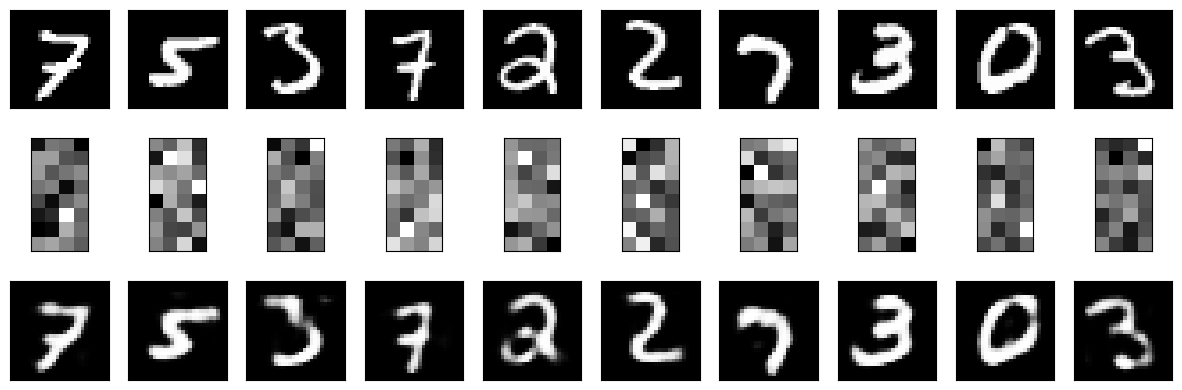

In [10]:
# take 1 batch of the dataset
test_dataset = test_dataset.take(1)

# take the input images and put them in a list
output_samples = []
for input_image, image in tfds.as_numpy(test_dataset):
      output_samples = input_image

# pick 10 random numbers to be used as indices to the list above
idxs = np.random.choice(BATCH_SIZE, size=10)

# get the encoder output
encoded_predicted = encoder_model.predict(test_dataset)

# get a prediction for the test batch
simple_predicted = autoencoder_model.predict(test_dataset)

# display the 10 samples, encodings and decoded values!
display_results(output_samples[idxs], encoded_predicted[idxs], simple_predicted[idxs])

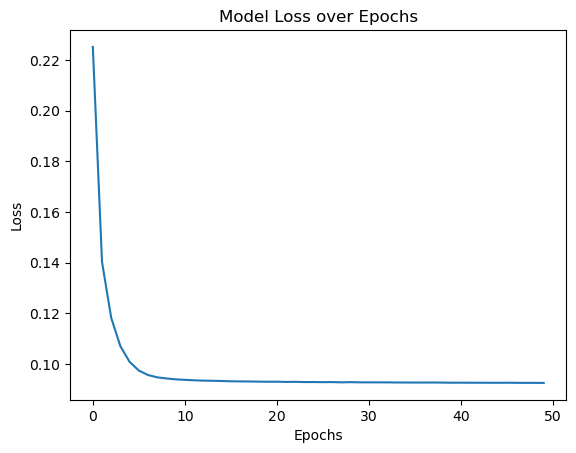

In [11]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(simple_auto_history.history['loss'])
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

[![Deep.png](https://i.postimg.cc/rp63MntX/Deep.png)](https://postimg.cc/JsqPQQqP)

In [5]:
import tensorflow as tf

def simple_autoencoder(inputs):
    """Builds a shallow autoencoder using Dense layers."""
    # Encoder
    encoder = tf.keras.layers.Dense(units=32, activation='relu')(inputs)
    # Decoder
    decoder = tf.keras.layers.Dense(units=784, activation='sigmoid')(encoder)

    # Build models
    encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder)
    autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder)

    return encoder_model, autoencoder_model


def deep_autoencoder(inputs):
    """Builds a deeper autoencoder using multiple Dense layers."""
    # Encoder
    encoder = tf.keras.layers.Dense(units=128, activation='relu')(inputs)
    encoder = tf.keras.layers.Dense(units=64, activation='relu')(encoder)
    encoder = tf.keras.layers.Dense(units=32, activation='relu')(encoder)

    # Decoder
    decoder = tf.keras.layers.Dense(units=64, activation='relu')(encoder)
    decoder = tf.keras.layers.Dense(units=128, activation='relu')(decoder)
    decoder = tf.keras.layers.Dense(units=784, activation='sigmoid')(decoder)

    # Build models
    encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder)
    autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder)

    return encoder_model, autoencoder_model

In [6]:
inputs = tf.keras.Input(shape=(784,))
simple_encoder, simple_autoencoder_model = simple_autoencoder(inputs)
deep_encoder, deep_autoencoder_model = deep_autoencoder(inputs)

In [7]:
simple_autoencoder_model.compile(optimizer='adam', loss='binary_crossentropy')
deep_autoencoder_model.compile(optimizer='adam', loss='binary_crossentropy')

In [8]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

history_simple = simple_autoencoder_model.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

history_deep = deep_autoencoder_model.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2792 - val_loss: 0.1941
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1736 - val_loss: 0.1553
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1454 - val_loss: 0.1343
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1289 - val_loss: 0.1216
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1185 - val_loss: 0.1131
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1113 - val_loss: 0.1071
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1060 - val_loss: 0.1027
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1022 - val_loss: 0.0993
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0994 - val_loss: 0.0971
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0975 - val_loss: 0.0955
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0963 - val_los

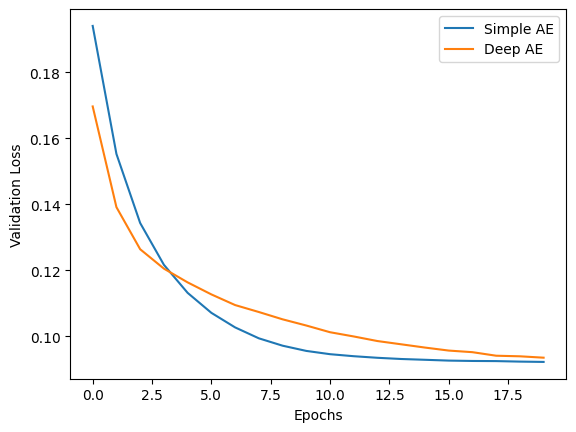

In [9]:
import matplotlib.pyplot as plt

plt.plot(history_simple.history['val_loss'], label='Simple AE')
plt.plot(history_deep.history['val_loss'], label='Deep AE')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()